# Comparison: Simulated Detections vs Original Biosample Data

This notebook compares the `detections.csv` generated by the POWTEX simulation with the `data_powtex_biosample.csv` provided by Irina Stefanescu.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define file paths
output_dir = Path('../data/output')
detections_file = output_dir / 'detections.csv'
biosample_file = output_dir / 'data_powtex_biosample.csv'

print(f"Loading data from:")
print(f"  - {detections_file}")
print(f"  - {biosample_file}")


Loading data from:
  - ../data/output/detections.csv
  - ../data/output/data_powtex_biosample.csv


In [55]:
# Load the detections data (simulated)
detections_df = pd.read_csv(detections_file, sep='\t')
print("Simulated Detections Data:")
print(f"  Shape: {detections_df.shape}")
print(f"  Columns: {list(detections_df.columns)}")
print(f"\nFirst few rows:")
print(detections_df.head())


Simulated Detections Data:
  Shape: (16452, 13)
  Columns: ['tof [ns]', 'lambda [A]', 'module', 'segment', 'counter', 'wire', 'strip', 'x_pos [mm]', 'y_pos [mm]', 'z_pos [mm]', 'voxel_x [mm]', 'voxel_y [mm]', 'voxel_z [mm]']

First few rows:
   tof [ns]  lambda [A]  module  segment  counter  wire  strip  x_pos [mm]  \
0  42603796     3.97200       9        7        2    14    115    1010.510   
1  42523085     3.97189       9        8        2     9    115     932.709   
2  42523085     3.97185       9        8        2     9    114     933.413   
3  42589005     3.97191      21        1        2     2     21    -524.783   
4  42573867     3.97193      31        1        1     1     20    -519.093   

   y_pos [mm]  z_pos [mm]  voxel_x [mm]  voxel_y [mm]  voxel_z [mm]  
0    -7.47973     156.070      1010.730       -11.121       155.803  
1    -4.64378     140.958       932.916        -0.764       143.788  
2    -3.75925     139.064       932.916        -0.764       135.900  
3  -627.9

In [56]:
# Load the biosample data (original)
biosample_df = pd.read_csv(biosample_file, sep='\t')
print("Original Biosample Data:")
print(f"  Shape: {biosample_df.shape}")
print(f"  Columns: {list(biosample_df.columns)}")
print(f"\nFirst few rows:")
print(biosample_df.head())


Original Biosample Data:
  Shape: (1134822, 13)
  Columns: ['tof [ns]', 'wavelength [angstrom]', 'module', 'segment', 'counter', 'wire', 'strip', 'x_pos [mm]', 'y_pos [mm]', 'z_pos [mm]', 'voxel_x [mm]', 'voxel_y [mm]', 'voxel_z [mm]']

First few rows:
   tof [ns]  wavelength [angstrom]  module  segment  counter  wire  strip  \
0  47210336                4.39322      18        8        1     2      8   
1  47210337                4.39345      18        8        1     1      8   
2  47044562                4.39327      27        3        1     3     37   
3  47027198                4.39296      23        1        2     2     37   
4  47131581                4.39344      19        5        1     2     20   

   x_pos [mm]  y_pos [mm]  z_pos [mm]  voxel_x [mm]  voxel_y [mm]  \
0    -124.235    -807.275    -740.141      -121.096      -814.011   
1    -123.202    -806.076    -738.370      -121.432      -798.277   
2    -788.012     276.894    -457.757      -792.081       275.078   
3    -77

## Data Overview & Column Mapping

The two datasets have similar structures but with different column naming conventions. Note that `lambda [A]` and `wavelength [angstrom]` represent the same physical quantity (neutron wavelength in Ångströms).


In [57]:
# Rename biosample columns to match detections for easier comparison
biosample_df_aligned = biosample_df.copy()
biosample_df_aligned = biosample_df_aligned.rename(columns={'wavelength [angstrom]': 'lambda [A]'})

# Create a comparison summary
comparison_summary = pd.DataFrame({
    'Metric': ['Total Events', 'Number of Columns', 'Time Range (ns)', 'Wavelength Range (A)', 'Module Range', 'Segment Range'],
    'Detections (Simulated)': [
        len(detections_df),
        len(detections_df.columns),
        f"{detections_df['tof [ns]'].min():.0f} - {detections_df['tof [ns]'].max():.0f}",
        f"{detections_df['lambda [A]'].min():.5f} - {detections_df['lambda [A]'].max():.5f}",
        f"{int(detections_df['module'].min())} - {int(detections_df['module'].max())}",
        f"{int(detections_df['segment'].min())} - {int(detections_df['segment'].max())}"
    ],
    'Biosample (Original)': [
        len(biosample_df_aligned),
        len(biosample_df_aligned.columns),
        f"{biosample_df_aligned['tof [ns]'].min():.0f} - {biosample_df_aligned['tof [ns]'].max():.0f}",
        f"{biosample_df_aligned['lambda [A]'].min():.5f} - {biosample_df_aligned['lambda [A]'].max():.5f}",
        f"{int(biosample_df_aligned['module'].min())} - {int(biosample_df_aligned['module'].max())}",
        f"{int(biosample_df_aligned['segment'].min())} - {int(biosample_df_aligned['segment'].max())}"
    ]
})

print("Comparison Summary:")
print(comparison_summary.to_string(index=False))


Comparison Summary:
              Metric Detections (Simulated) Biosample (Original)
        Total Events                  16452              1134822
   Number of Columns                     13                   13
     Time Range (ns)    12874290 - 48923419  15326445 - 51551674
Wavelength Range (A)      1.20372 - 4.58386    1.41493 - 4.79705
        Module Range                 1 - 32               1 - 32
       Segment Range                  1 - 8                1 - 8


## Statistical Comparison

Compare statistical properties of key columns between simulated and original data.


In [66]:
# Statistical comparison for key continuous variables
numeric_cols = ['tof [ns]', 'lambda [A]', 'x_pos [mm]', 'y_pos [mm]', 'z_pos [mm]', 
                'voxel_x [mm]', 'voxel_y [mm]', 'voxel_z [mm]']

print("=" * 80)
print("STATISTICAL COMPARISON - SIMULATED vs ORIGINAL DATA")
print("=" * 80)

for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  {'Metric':<20} {'Detections (Sim)':<25} {'Biosample (Orig)':<25}")
    print(f"  {'-'*20} {'-'*25} {'-'*25}")
    
    stats_sim = detections_df[col].describe()
    stats_orig = biosample_df_aligned[col].describe()
    
    for stat in ['count', 'mean', 'std', 'min', 'max']:
        print(f"  {stat:<20} {stats_sim[stat]:<25.4f} {stats_orig[stat]:<25.4f}")


STATISTICAL COMPARISON - SIMULATED vs ORIGINAL DATA

tof [ns]:
  Metric               Detections (Sim)          Biosample (Orig)         
  -------------------- ------------------------- -------------------------
  count                16452.0000                1134822.0000             
  mean                 33956159.9812             34542916.5043            
  std                  14533570.3237             7510187.0654             
  min                  12874290.0000             15326445.0000            
  max                  48923419.0000             51551674.0000            

lambda [A]:
  Metric               Detections (Sim)          Biosample (Orig)         
  -------------------- ------------------------- -------------------------
  count                16452.0000                1134822.0000             
  mean                 3.1702                    3.2259                   
  std                  1.3574                    0.7043                   
  min                  1

## Categorical Variable Distributions


In [59]:
# Compare categorical distributions
cat_cols = ['module', 'segment', 'counter', 'wire', 'strip']

print("CATEGORICAL VARIABLE COMPARISON")
print("=" * 100)

for col in cat_cols:
    print(f"\n{col.upper()}:")
    print(f"  Unique values in Simulated:  {detections_df[col].nunique()}")
    print(f"  Unique values in Original:   {biosample_df_aligned[col].nunique()}")
    print(f"  Range (Simulated):  {int(detections_df[col].min())} - {int(detections_df[col].max())}")
    print(f"  Range (Original):   {int(biosample_df_aligned[col].min())} - {int(biosample_df_aligned[col].max())}")


CATEGORICAL VARIABLE COMPARISON

MODULE:
  Unique values in Simulated:  32
  Unique values in Original:   32
  Range (Simulated):  1 - 32
  Range (Original):   1 - 32

SEGMENT:
  Unique values in Simulated:  8
  Unique values in Original:   8
  Range (Simulated):  1 - 8
  Range (Original):   1 - 8

COUNTER:
  Unique values in Simulated:  2
  Unique values in Original:   2
  Range (Simulated):  1 - 2
  Range (Original):   1 - 2

WIRE:
  Unique values in Simulated:  16
  Unique values in Original:   16
  Range (Simulated):  1 - 16
  Range (Original):   1 - 16

STRIP:
  Unique values in Simulated:  192
  Unique values in Original:   192
  Range (Simulated):  1 - 192
  Range (Original):   1 - 192


## Distribution Visualizations

Compare key variable distributions between simulated and original data.


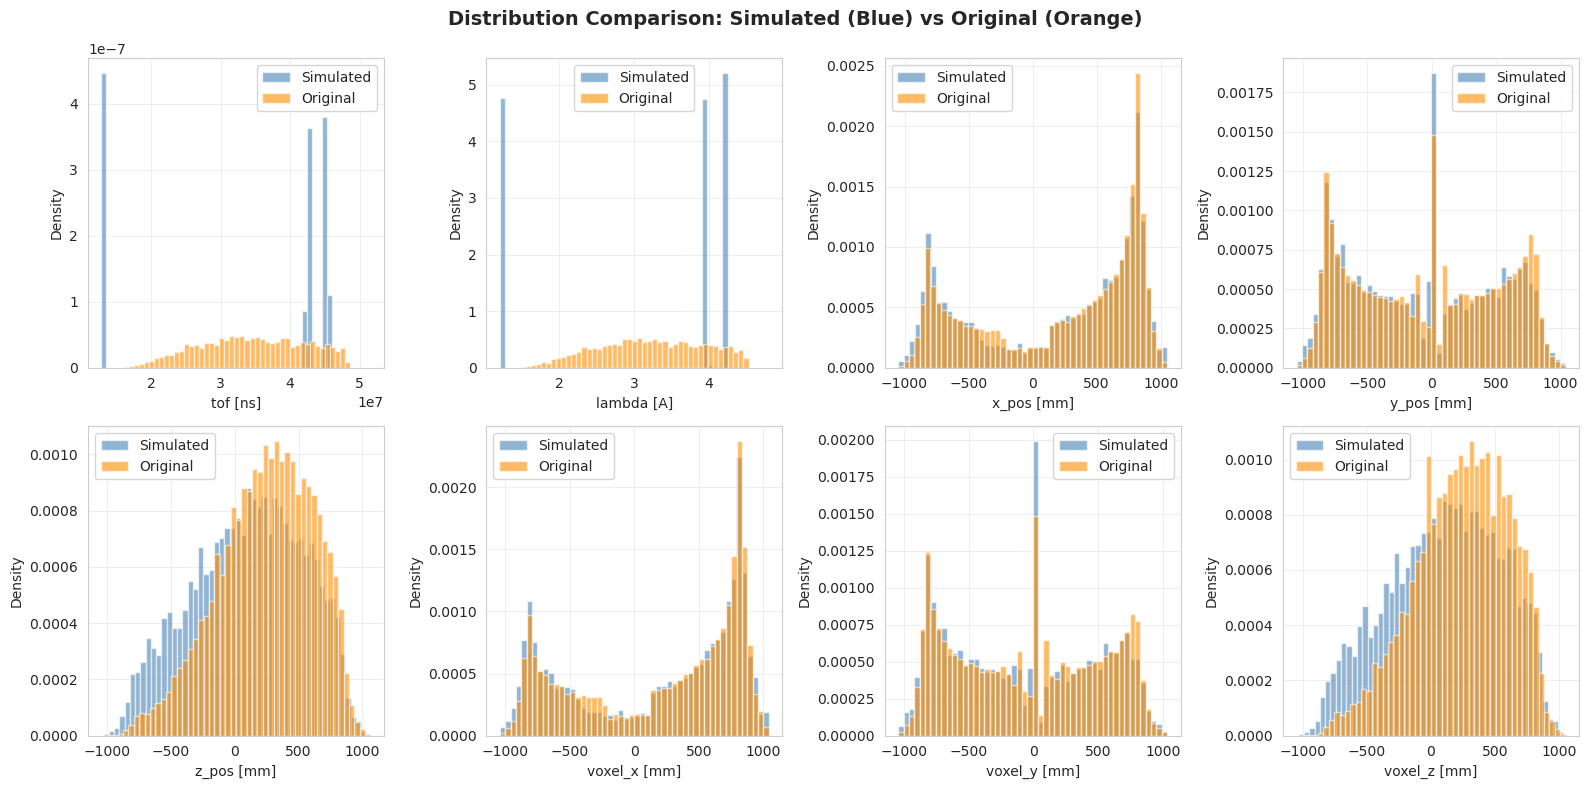

In [60]:
# Visualize distributions of key continuous variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution Comparison: Simulated (Blue) vs Original (Orange)', fontsize=14, fontweight='bold')

plot_cols = ['tof [ns]', 'lambda [A]', 'x_pos [mm]', 'y_pos [mm]', 
             'z_pos [mm]', 'voxel_x [mm]', 'voxel_y [mm]', 'voxel_z [mm]']

for idx, col in enumerate(plot_cols):
    ax = axes[idx // 4, idx % 4]
    
    ax.hist(detections_df[col], bins=50, alpha=0.6, label='Simulated', color='steelblue', density=True)
    ax.hist(biosample_df_aligned[col], bins=50, alpha=0.6, label='Original', color='darkorange', density=True)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()